# Spatial Correlation Taylor Plots (not temporal correlation)

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import skill_metrics as sm
import warnings
from glob import glob
from scipy.stats import wasserstein_distance

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.mpl.geoaxes as cgeo

warnings.filterwarnings("ignore")

# WRF

In [2]:
topography = xr.open_dataset("/users/rpayne/data/topography/hr/HGT_orig.nc")

# climatological ws10

winds_ubc_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/WS10/wrfubc_ctl_WS10_yseasmean_200010_201509.nc")
winds_ubc_ds['WS10'] = winds_ubc_ds['WS10'] * 3.6  # convert to km/h

winds_usask_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-USASK/ctl/WS10/merged/no_regrid/WS10_yseasmean_200010_201508.nc")
winds_usask_ds['WS10'] = winds_usask_ds['WS10'] * 3.6  # convert to km/h

# climatological ws10 daily maximum

winds_dmax_ubc_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/WS10/wrfubc_ctl_WS10_daymax_yseasmean_200010_201509.nc")
winds_dmax_ubc_ds['WS10'] = winds_dmax_ubc_ds['WS10'] * 3.6  # convert to km/h

winds_dmax_usask_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-USASK/ctl/WS10/merged/no_regrid/WS10_dailymax_yseasmean_200010_201508.nc")
winds_dmax_usask_ds['WS10'] = winds_dmax_usask_ds['WS10'] * 3.6  # convert to km/h

# climatological q2

humid_ubc_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/Q2/wrfubc_ctl_Q2_yseasmean_200010_201509.nc")

humid_usask_ds = xr.open_dataset("/users/rpayne/data/unproc/WRF-USASK/ctl/Q2/merged/no_regrid/Q2_yseasmean_200010_201508.nc")

# Stns

In [3]:
# Constants

START_DATE = np.datetime64('2000-10-01T00:00:00.000000000')
END_DATE = np.datetime64('2015-08-31T23:00:00.000000000')
N_HOURS = (END_DATE - START_DATE) / np.timedelta64(1, 'h') + 1
N_DAYS = np.round((END_DATE - START_DATE) / np.timedelta64(1, 'D'))
print(N_HOURS, N_DAYS)

COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)

SEASON_MAP = {12: "DJF", 1: "DJF", 2: "DJF",
              3: "MAM", 4: "MAM", 5: "MAM",
              6: "JJA", 7: "JJA", 8: "JJA",
              9: "SON", 10: "SON", 11: "SON"}

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

130752.0 5448.0


In [4]:
# file = "/users/rpayne/data/unproc/STN_ECCC/api/hourly/merged/ec_hourly_allstns.csv"
# # file = "/users/rpayne/data/unproc/STN_ECCC/api/hourly/ec_hourly_id409.csv"
# df = pd.read_csv(file, encoding="utf-8", low_memory=False, index_col=4, parse_dates=True)
# stn_names = df['Station Name'].unique()
# FIRST_YEAR = 1990
# LAST_YEAR = 2023
# full_index = pd.date_range(f"{FIRST_YEAR}-01-01 00:00:00", f"{LAST_YEAR}-12-31 23:00:00", freq="H")
# for i, stn in enumerate(stn_names):
#     print(i, stn)
#     df[df['Station Name'] == stn] = df[df['Station Name'] == stn].reindex(full_index)
# df

In [5]:
# for i, stn in enumerate(stn_names):
#     print(i, stn, df[df['Station Name'] == stn].index.is_unique)

In [6]:
# Takes ~5 minutes to run

wx_data_fnames = sorted(glob("/users/rpayne/data/unproc/STN_ECCC/api/hourly/*.csv"))
df = pd.concat(
    (pd.read_csv(f, encoding='latin1', low_memory=False) for f in wx_data_fnames),
    ignore_index=True
)
df['Date/Time (LST)'] = pd.to_datetime(df['Date/Time (LST)'], format='%Y-%m-%d %H:%M:%S')
df = df[df['Date/Time (LST)'] >= START_DATE]  # Filter for data to align w WRF
df = df[df['Date/Time (LST)'] <= END_DATE]
df.set_index('Date/Time (LST)', inplace=True)
df.rename(columns={"Temp (Â°C)": "Temp (°C)"}, inplace=True)
df.rename(columns={"Dew Point Temp (Â°C)": "Dew Point Temp (°C)"}, inplace=True)
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Flag,Temp (°C),...,Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,Precip. Amount (mm),Precip. Amount Flag
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2000-10-01 00:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,00:00,NaN,-2.3,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 01:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,01:00,NaN,-1.8,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 02:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,02:00,NaN,-1.2,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 03:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,03:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 04:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,04:00,NaN,0.3,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-08-31 19:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2015,8,31,19:00,NaN,15.1,...,NaN,95.46,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2015-08-31 20:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2015,8,31,20:00,NaN,14.7,...,NaN,95.45,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2015-08-31 21:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2015,8,31,21:00,NaN,15.3,...,NaN,95.45,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [7]:
def get_stn(stn_name, data=df):
    stn = data[data["Station Name"] == stn_name]
    stn = stn.sort_index()
    stn = stn[~stn.index.duplicated(keep='last')]
    # stn = stn.reindex(full_time_index)
    return stn

In [8]:
# Create a dictionary mapping station name to (lat, lon) from df
stn_latlon = {}
stns = df["Station Name"].unique()
for stn in stns:
    stn_rows = df[df["Station Name"] == stn]
    if not stn_rows.empty:
        lat = stn_rows["Latitude (y)"].iloc[0]
        lon = stn_rows["Longitude (x)"].iloc[0]
        stn_latlon[stn] = (lat, lon)
    else:
        stn_latlon[stn] = (None, None)


def get_stn(stn_name, data=df):
    stn = data[data["Station Name"] == stn_name]
    stn = stn.sort_index()
    stn = stn[~stn.index.duplicated(keep='last')]
    # stn = stn.reindex(full_time_index)
    return stn

In [9]:
# Find all stations that meet the coverage threshold for winds and humidity

WS_coverage_dict = {}
Q2_coverage_dict = {}

m_v = 18.01528e-3 # kg/mol
m_d = 28.9647e-3 # kg/mol
e0 = 0.611 # kPa
T0 = 273.15 # K
L_v = 2.45e6 # J/kg
R = 8.314 # J/(mol*K)
df["Specific Humidity (kg/kg)"] = np.exp((m_v * L_v / R) * (1/T0 - 1/(df["Dew Point Temp (°C)"] + 273.15))) * (m_v/m_d) * (e0 / df["Stn Press (kPa)"])

for i,stn in enumerate(stns):
    print(f"{i+1}/{len(stns)}")
    
    stn_data = get_stn(stn)

    WS_data = stn_data["Wind Spd (km/h)"].resample('D').max()
    Q2_data = stn_data["Specific Humidity (kg/kg)"].resample('D').mean()
    
    WS_coverage = np.count_nonzero(~np.isnan(WS_data)) / N_DAYS
    Q2_coverage = np.count_nonzero(~np.isnan(Q2_data)) / N_DAYS

    if WS_coverage >= COVERAGE_THRESHOLD:
        WS_coverage_dict[stn] = WS_coverage
    if Q2_coverage >= COVERAGE_THRESHOLD:
        Q2_coverage_dict[stn] = Q2_coverage

print(f"Number of stations with adequate Wind Speed coverage: {len(WS_coverage_dict)}")
print(f"Number of stations with adequate Specific Humidity coverage: {len(Q2_coverage_dict)}")

1/364
2/364
3/364
4/364
5/364
6/364
7/364
8/364
9/364
10/364
11/364
12/364
13/364
14/364
15/364
16/364
17/364
18/364
19/364
20/364
21/364
22/364
23/364
24/364
25/364
26/364
27/364
28/364
29/364
30/364
31/364
32/364
33/364
34/364
35/364
36/364
37/364
38/364
39/364
40/364
41/364
42/364
43/364
44/364
45/364
46/364
47/364
48/364
49/364
50/364
51/364
52/364
53/364
54/364
55/364
56/364
57/364
58/364
59/364
60/364
61/364
62/364
63/364
64/364
65/364
66/364
67/364
68/364
69/364
70/364
71/364
72/364
73/364
74/364
75/364
76/364
77/364
78/364
79/364
80/364
81/364
82/364
83/364
84/364
85/364
86/364
87/364
88/364
89/364
90/364
91/364
92/364
93/364
94/364
95/364
96/364
97/364
98/364
99/364
100/364
101/364
102/364
103/364
104/364
105/364
106/364
107/364
108/364
109/364
110/364
111/364
112/364
113/364
114/364
115/364
116/364
117/364
118/364
119/364
120/364
121/364
122/364
123/364
124/364
125/364
126/364
127/364
128/364
129/364
130/364
131/364
132/364
133/364
134/364
135/364
136/364
137/364
138/364
139/

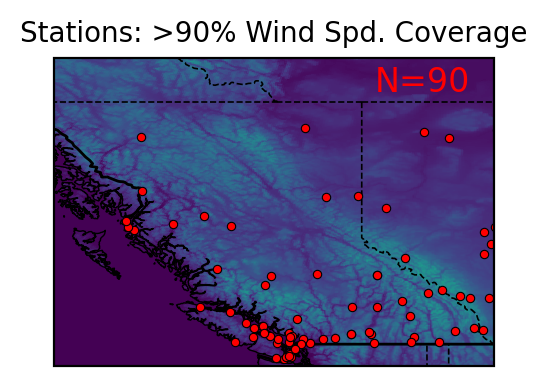

In [10]:
lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()

# Create a figure
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()},figsize=(4,2),dpi=200)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto')
ax.coastlines(linewidth=0.5,zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)
for stn in WS_coverage_dict.keys():
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())
ax.set_xlim(-134, -114)
ax.set_ylim(48, 62)
ax.text(-119.4, 60.5, f"N={len(WS_coverage_dict.keys())}", fontsize=12, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"Stations: >{100*COVERAGE_THRESHOLD:.0f}% Wind Spd. Coverage", fontsize=10)
plt.show()

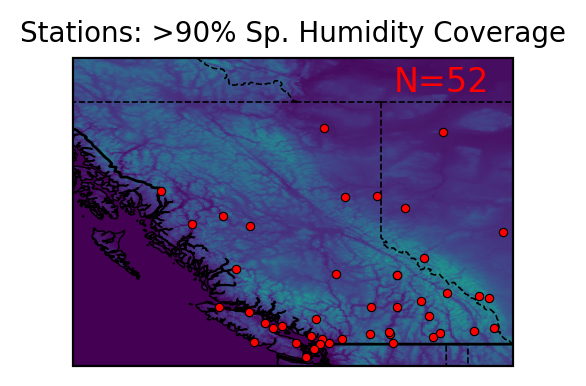

In [11]:
lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()

# Create a figure
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()},figsize=(4,2),dpi=200)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto')
ax.coastlines(linewidth=0.5,zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)
for stn in Q2_coverage_dict.keys():
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())
ax.set_xlim(-134, -114)
ax.set_ylim(48, 62)
ax.text(-119.4, 60.5, f"N={len(Q2_coverage_dict.keys())}", fontsize=12, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"Stations: >{100*COVERAGE_THRESHOLD:.0f}% Sp. Humidity Coverage", fontsize=10)
plt.show()

# Taylor Diagrams

In [12]:
def get_nearest_wrf_point(ds, lat, lon):
    try:
        abs_lat = np.abs(ds['XLAT'] - lat)
        abs_lon = np.abs(ds['XLONG'] - lon)
    except:
        abs_lat = np.abs(ds['lat'] - lat)
        abs_lon = np.abs(ds['lon'] - lon)
    dist = abs_lat + abs_lon
    idx = np.unravel_index(np.argmin(dist.values), dist.shape)
    return idx

In [13]:
# ------------------------------------------------------------------
# Get and store the data needed to calculate the Taylor statistics
# ------------------------------------------------------------------

# initialize dictionaries used to store data for Taylor stats
keys = ["Winds", "Winds Daily Max", "Humid"]
subkeys = ["DJF", "MAM", "JJA", "SON"]
stn_vals = {k: {s: [] for s in subkeys} for k in keys}
wrf_ubc_vals = {k: {s: [] for s in subkeys} for k in keys}
wrf_usask_vals = {k: {s: [] for s in subkeys} for k in keys}

# get data
for j, season in enumerate(subkeys):

    print(f"Working on Q2 for {season}...")

    # loop over each station with adequate coverage of HUMIDITY
    for i, stn in enumerate(sorted(Q2_coverage_dict.keys())):

        # Get station mean for the season
        data = get_stn(stn)
        lat = stn_latlon[stn][0]
        lon = stn_latlon[stn][1]
        start_time = data.index.min().to_datetime64()
        end_time = data.index.max().to_datetime64()
        stn_humid = data["Specific Humidity (kg/kg)"].reset_index()
        stn_humid['Season'] = stn_humid['Date/Time (LST)'].dt.month.map(SEASON_MAP)

        stn_humid_seasonal_mean = stn_humid.groupby('Season')["Specific Humidity (kg/kg)"].mean()[season]
        if np.isnan(stn_humid_seasonal_mean):
            print(f"Skipping {stn} for {season} due to NaN mean in humidity")
            continue

        # Get model mean for the season at the nearest grid point to the stn
        nearest_idx_ubc = get_nearest_wrf_point(humid_ubc_ds, lat, lon)
        nearest_idx_usask = get_nearest_wrf_point(humid_usask_ds, lat, lon)
        wrf_humid_ubc_seasonal_mean = humid_ubc_ds.isel(south_north=nearest_idx_ubc[0], west_east=nearest_idx_ubc[1], Times=j)['Q2'].values
        wrf_humid_usask_seasonal_mean = humid_usask_ds.isel(rlat=nearest_idx_usask[0], rlon=nearest_idx_usask[1], time=j)['Q2'].values

        # append to dictionaries
        stn_vals["Humid"][season].append(stn_humid_seasonal_mean)
        wrf_ubc_vals["Humid"][season].append(wrf_humid_ubc_seasonal_mean)
        wrf_usask_vals["Humid"][season].append(wrf_humid_usask_seasonal_mean)

    print(f"Working on WS10 for {season}...")

    # loop over each station with adequate coverage of WINDS
    for i, stn in enumerate(sorted(WS_coverage_dict.keys())):

        # Get station mean for the season
        data = get_stn(stn)
        lat = stn_latlon[stn][0]
        lon = stn_latlon[stn][1]
        start_time = data.index.min().to_datetime64()
        end_time = data.index.max().to_datetime64()
        stn_winds = data["Wind Spd (km/h)"].reset_index()
        stn_winds_dmax = stn_winds.set_index('Date/Time (LST)').resample('D').max().reset_index()
        stn_winds['Season'] = stn_winds['Date/Time (LST)'].dt.month.map(SEASON_MAP)
        stn_winds_dmax['Season'] = stn_winds_dmax['Date/Time (LST)'].dt.month.map(SEASON_MAP)

        stn_winds_seasonal_mean = stn_winds.groupby('Season')["Wind Spd (km/h)"].mean()[season]
        stn_winds_dmax_seasonal_mean = stn_winds_dmax.groupby('Season')["Wind Spd (km/h)"].mean()[season]
        if np.isnan(stn_winds_seasonal_mean) or np.isnan(stn_winds_dmax_seasonal_mean):
            print(f"Skipping {stn} for {season} due to NaN mean in winds")
            continue

        # Get model mean for the season at the nearest grid point to the stn
        nearest_idx_ubc = get_nearest_wrf_point(winds_ubc_ds, lat, lon)
        nearest_idx_usask = get_nearest_wrf_point(winds_usask_ds, lat, lon)
        wrf_winds_ubc_seasonal_mean = winds_ubc_ds.isel(south_north=nearest_idx_ubc[0], west_east=nearest_idx_ubc[1], Times=j)['WS10'].values
        wrf_winds_usask_seasonal_mean = winds_usask_ds.isel(rlat=nearest_idx_usask[0], rlon=nearest_idx_usask[1], time=j)['WS10'].values
        wrf_winds_dmax_ubc_seasonal_mean = winds_dmax_ubc_ds.isel(south_north=nearest_idx_ubc[0], west_east=nearest_idx_ubc[1], Times=j)['WS10'].values
        wrf_winds_dmax_usask_seasonal_mean = winds_dmax_usask_ds.isel(rlat=nearest_idx_usask[0], rlon=nearest_idx_usask[1], time=j)['WS10'].values

        # append to dictionaries
        stn_vals["Winds"][season].append(stn_winds_seasonal_mean)
        wrf_ubc_vals["Winds"][season].append(wrf_winds_ubc_seasonal_mean)
        wrf_usask_vals["Winds"][season].append(wrf_winds_usask_seasonal_mean)
        stn_vals["Winds Daily Max"][season].append(stn_winds_dmax_seasonal_mean)
        wrf_ubc_vals["Winds Daily Max"][season].append(wrf_winds_dmax_ubc_seasonal_mean)
        wrf_usask_vals["Winds Daily Max"][season].append(wrf_winds_dmax_usask_seasonal_mean)


Working on Q2 for DJF...


Working on WS10 for DJF...
Working on Q2 for MAM...
Working on WS10 for MAM...
Working on Q2 for JJA...
Working on WS10 for JJA...
Working on Q2 for SON...
Working on WS10 for SON...


In [14]:
def get_crmse_text_loc (rlim, radius):
    x = 1 - radius / np.sqrt(1 + np.pow(rlim, 2))
    y = rlim * (1 - x)
    return (x,y)

def plot_point(r, theta, ax=None, marker='o', col='red', edgecol='k', text=None, fs=7, label=None, lw=0.6):
    if ax is None:
        ax = plt.gca()
    if text is not None:
        ax.text(np.pi/2 - theta - .034, r + .017, text, ha='center', va='center', fontsize=fs, color=col, zorder=11)
    else:
        ax.scatter(np.pi/2 - theta, r, marker=marker, facecolor=col, edgecolor=edgecol, linewidth=lw, zorder=10, s=30, label=label)

def initialize_axis(ax, add_ylabel=True):
    rlim = 1.5
    dr = .25
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(225)
    if add_ylabel:
        ax.set_ylabel('Standard Deviation (Normalized)')
    ax.set_yticks(np.arange(0, rlim + dr, dr))
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(0, rlim)
    ax.set_thetamin(0)
    ax.set_thetamax(90)

    corr_ticklabels = np.array([0,1,2,3,4,5,6,7,8,9,9.5,9.9,10])/10.
    corr_ticks = np.arcsin(corr_ticklabels)
    ax.set_thetagrids(np.degrees(corr_ticks), labels=corr_ticklabels)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(color='grey',linestyle='--')
    # circle = plt.Circle((0, 0), 1, transform=ax.transData._b, color='k', fill=False, linewidth=.5, linestyle='-', zorder=8)
    # ax.add_artist(circle)

    for j, diam in enumerate([.5, 1, 1.5]):
        circle = plt.Circle((1, 0), diam, transform=ax.transData._b, color='blue', fill=False, linewidth=1, linestyle=':')
        ax.add_artist(circle)
        eps = 2e-2
        x_text, y_text = get_crmse_text_loc(rlim, diam)
        ax.text(
            x_text - eps, y_text - 2.5*eps, f"{diam:.1f}", transform=ax.transData._b,
            color='blue', fontsize=10, ha='center', va='bottom',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1'),
            rotation=np.arctan(1/rlim)*(180/np.pi),
        )

    ax.text(np.pi/4, rlim + .17, 'Correlation Coefficient', ha='center', va='center', color='k', fontsize=10, rotation=-45, zorder=9)
    ax.text(1,0+.045, '.', transform=ax.transData._b, ha='center', va='center', color='k', fontsize=40, zorder=9)
    ax.text(1,0-.045, 'Obsv.', transform=ax.transData._b, ha='center', va='center', color='k', fontsize=7, rotation=0, zorder=9)

Plotting Winds for DJF...
Plotting Winds for MAM...
Plotting Winds for JJA...
Plotting Winds for SON...
Plotting Winds Daily Max for DJF...
Plotting Winds Daily Max for MAM...
Plotting Winds Daily Max for JJA...
Plotting Winds Daily Max for SON...
Plotting Humid for DJF...
Plotting Humid for MAM...
Plotting Humid for JJA...
Plotting Humid for SON...


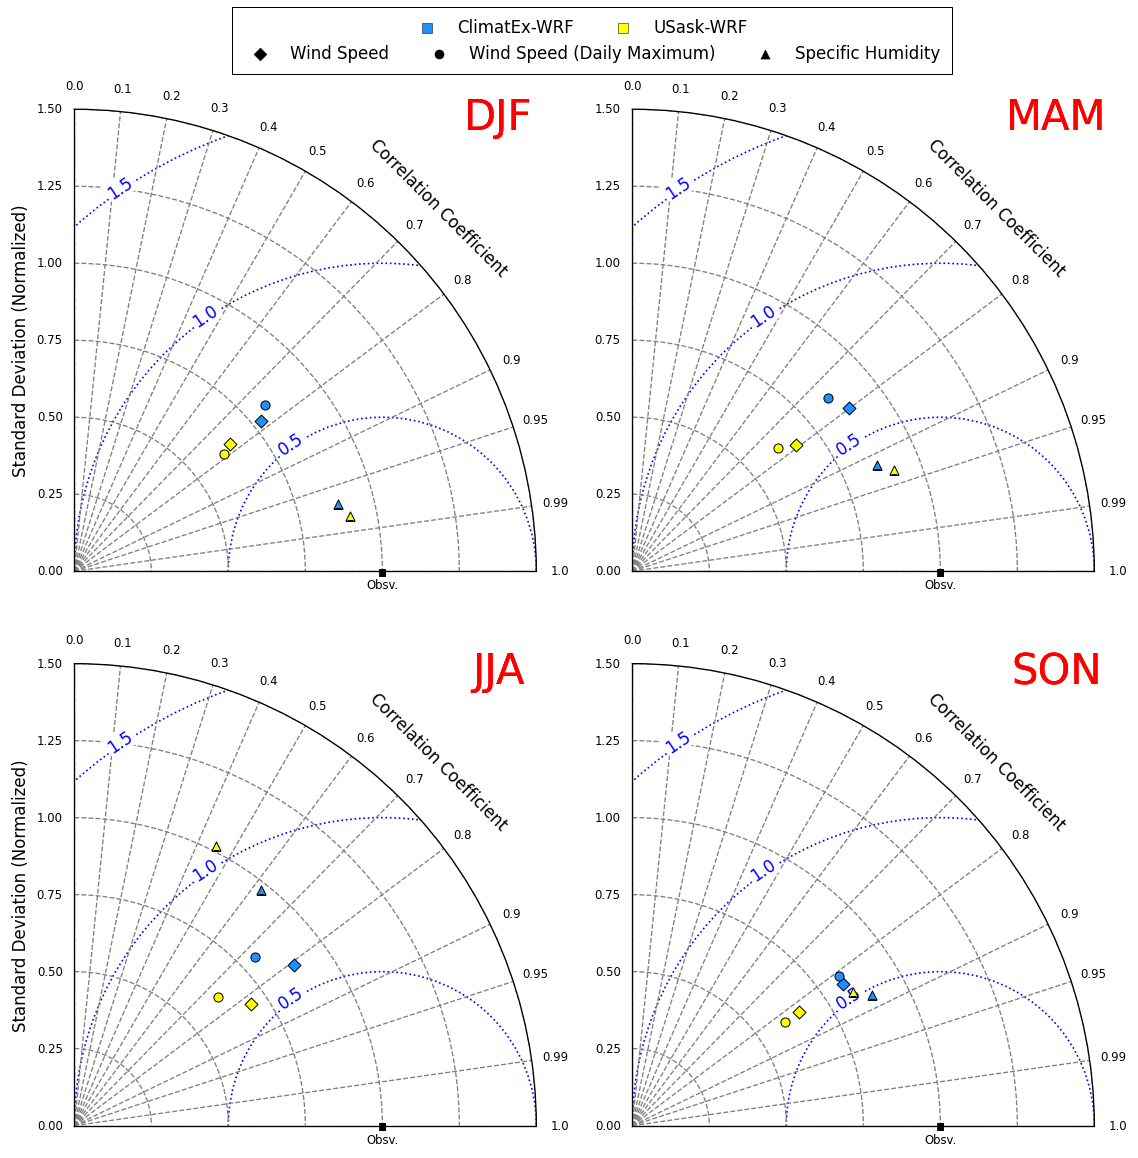

In [47]:
# ------------------------------------------------------------------
# Set up the plot structure
# ------------------------------------------------------------------

fig = plt.figure(figsize=(11, 11), dpi=120)
ax0 = fig.add_subplot(221, polar=True)
ax1 = fig.add_subplot(222, polar=True)
ax2 = fig.add_subplot(223, polar=True)
ax3 = fig.add_subplot(224, polar=True)
axes = [ax0, ax1, ax2, ax3]
initialize_axis(ax0, add_ylabel=True)
initialize_axis(ax1, add_ylabel=False)
initialize_axis(ax2, add_ylabel=True)
initialize_axis(ax3, add_ylabel=False)

# ------------------------------------------------------------------
# Plot the data on the Taylor diagram
# ------------------------------------------------------------------

markers = ['D', 'o', '^',]  # Denote variable (winds, winds dmax, humid)
colours = ['dodgerblue', 'yellow',]  # Denote Model (UBC WRF, USASK WRF)
std_norm, rms_norm, corr = [1.], [0.], [1.]

# Loop over each variable (winds, humid) and each season
for i, var in enumerate(keys):
    for j, season in enumerate(subkeys):
        
        print(f"Plotting {var} for {season}...")

        # compute taylor statistics for var (UBC WRF) and plot
        stats_ubc = sm.taylor_statistics(wrf_ubc_vals[var][season], stn_vals[var][season])
        std_norm.append(stats_ubc['sdev'][1] / stats_ubc['sdev'][0])
        rms_norm.append(stats_ubc['crmsd'][1] / stats_ubc['sdev'][0])
        corr.append(stats_ubc['ccoef'][1])
        if (corr[-1] < 0) or np.isnan(corr[-1]):
            print(f"WARNING: Negative or NaN correlation for variable {var} and season {season} in UBC WRF")
        plot_point(std_norm[-1], np.arccos(corr[-1]), marker=markers[i], col=colours[0], edgecol='k', ax=axes[j])
        # plot_point(std_norm[-1], np.arccos(corr[-1]), text=f"1", ax=axes[j], col='k')

        # compute taylor statistics for var (USASK WRF) and plot
        stats_usask = sm.taylor_statistics(wrf_usask_vals[var][season], stn_vals[var][season])
        std_norm.append(stats_usask['sdev'][1] / stats_usask['sdev'][0])
        rms_norm.append(stats_usask['crmsd'][1] / stats_usask['sdev'][0])
        corr.append(stats_usask['ccoef'][1])
        if (corr[-1] < 0) or np.isnan(corr[-1]):
            print(f"WARNING: Negative or NaN correlation for variable {var} and season {season} in USask WRF")
        plot_point(std_norm[-1], np.arccos(corr[-1]), marker=markers[i], col=colours[1], edgecol='k', ax=axes[j])
        # plot_point(std_norm[-1], np.arccos(corr[-1]), text=f"2", ax=axes[j], col='k')

        # add text for specifying season in the top right of each subplot
        plot_point(2, np.pi/4, text=f"{season}", ax=axes[j], col='red', fs=25)

# legend
plot_point(-1, -1, marker='s', ax=axes[0], col=colours[0], fs=0, lw=0.3, label='ClimatEx-WRF')
plot_point(-1, -1, marker='s', ax=axes[0], col=colours[1], fs=0, lw=0.3, label='USask-WRF')
plot_point(-1, -1, marker=markers[0], ax=axes[1], col='k', fs=0, lw=0.3, label='Wind Speed')
plot_point(-1, -1, marker=markers[1], ax=axes[1], col='k', fs=0, lw=0.3, label='Wind Speed (Daily Maximum)')
plot_point(-1, -1, marker=markers[2], ax=axes[1], col='k', fs=0, lw=0.3, label='Specific Humidity')

axes[0].legend(loc='upper right', fontsize=10, frameon=False, ncols=2, bbox_to_anchor=(1.49, 1.23),)
axes[1].legend(loc='upper right', fontsize=10, frameon=False, ncols=3, bbox_to_anchor=(.7, 1.23),)
leg0 = axes[0].get_legend()
leg1 = axes[1].get_legend()
leg1.set_frame_on(True)
frame = leg1.get_frame()
frame.set_boxstyle("square,pad=0.28")
frame.set_facecolor("none")
frame.set_edgecolor("black")
frame.set_linewidth(0.6)
frame.set_alpha(1.0)
leg1.set_title(" ", prop={"size": 10})

plt.show()

Plotting Winds for DJF...
Plotting Winds for MAM...
Plotting Winds for JJA...
Plotting Winds for SON...
Plotting Winds Daily Max for DJF...
Plotting Winds Daily Max for MAM...
Plotting Winds Daily Max for JJA...
Plotting Winds Daily Max for SON...


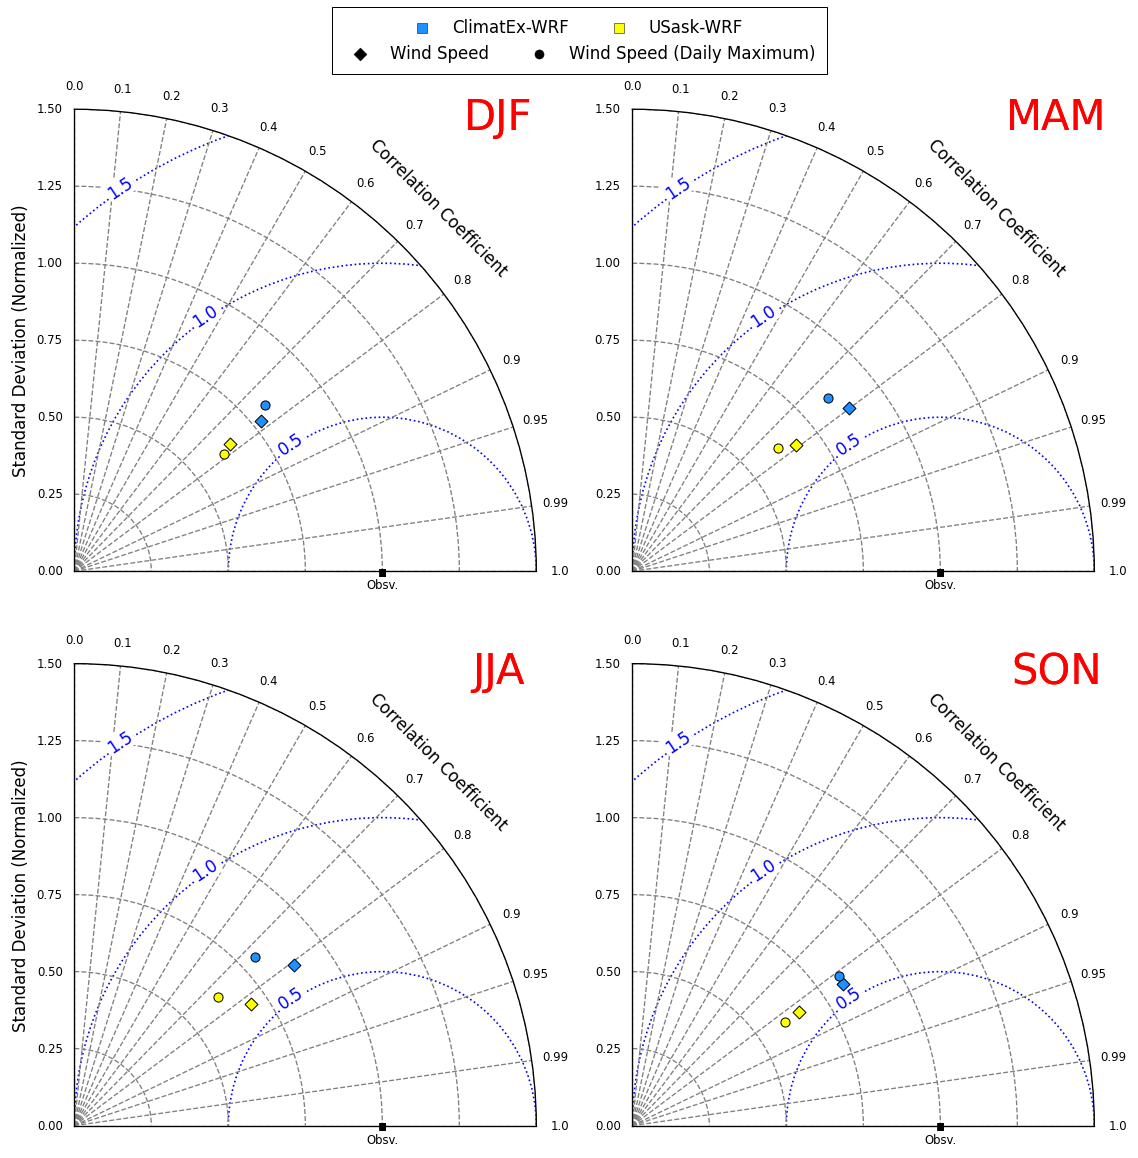

In [45]:
# JUST WINDS

# ------------------------------------------------------------------
# Set up the plot structure
# ------------------------------------------------------------------

fig = plt.figure(figsize=(11, 11), dpi=120)
ax0 = fig.add_subplot(221, polar=True)
ax1 = fig.add_subplot(222, polar=True)
ax2 = fig.add_subplot(223, polar=True)
ax3 = fig.add_subplot(224, polar=True)
axes = [ax0, ax1, ax2, ax3]
initialize_axis(ax0, add_ylabel=True)
initialize_axis(ax1, add_ylabel=False)
initialize_axis(ax2, add_ylabel=True)
initialize_axis(ax3, add_ylabel=False)

# ------------------------------------------------------------------
# Plot the data on the Taylor diagram
# ------------------------------------------------------------------

markers = ['D', 'o', '^',]  # Denote variable (winds, winds dmax, humid)
colours = ['dodgerblue', 'yellow',]  # Denote Model (UBC WRF, USASK WRF)
std_norm, rms_norm, corr = [1.], [0.], [1.]

# Loop over each variable (winds, humid) and each season
for i, var in enumerate(keys[:-1]):
    for j, season in enumerate(subkeys):
        
        print(f"Plotting {var} for {season}...")

        # compute taylor statistics for var (UBC WRF) and plot
        stats_ubc = sm.taylor_statistics(wrf_ubc_vals[var][season], stn_vals[var][season])
        std_norm.append(stats_ubc['sdev'][1] / stats_ubc['sdev'][0])
        rms_norm.append(stats_ubc['crmsd'][1] / stats_ubc['sdev'][0])
        corr.append(stats_ubc['ccoef'][1])
        if (corr[-1] < 0) or np.isnan(corr[-1]):
            print(f"WARNING: Negative or NaN correlation for variable {var} and season {season} in UBC WRF")
        plot_point(std_norm[-1], np.arccos(corr[-1]), marker=markers[i], col=colours[0], edgecol='k', ax=axes[j])
        # plot_point(std_norm[-1], np.arccos(corr[-1]), text=f"1", ax=axes[j], col='k')

        # compute taylor statistics for var (USASK WRF) and plot
        stats_usask = sm.taylor_statistics(wrf_usask_vals[var][season], stn_vals[var][season])
        std_norm.append(stats_usask['sdev'][1] / stats_usask['sdev'][0])
        rms_norm.append(stats_usask['crmsd'][1] / stats_usask['sdev'][0])
        corr.append(stats_usask['ccoef'][1])
        if (corr[-1] < 0) or np.isnan(corr[-1]):
            print(f"WARNING: Negative or NaN correlation for variable {var} and season {season} in USask WRF")
        plot_point(std_norm[-1], np.arccos(corr[-1]), marker=markers[i], col=colours[1], edgecol='k', ax=axes[j])
        # plot_point(std_norm[-1], np.arccos(corr[-1]), text=f"2", ax=axes[j], col='k')

        # add text for specifying season in the top right of each subplot
        plot_point(2, np.pi/4, text=f"{season}", ax=axes[j], col='red', fs=25)

# legend
plot_point(-1, -1, marker='s', ax=axes[0], col=colours[0], fs=0, lw=0.3, label='ClimatEx-WRF')
plot_point(-1, -1, marker='s', ax=axes[0], col=colours[1], fs=0, lw=0.3, label='USask-WRF')
plot_point(-1, -1, marker=markers[0], ax=axes[1], col='k', fs=0, lw=0.3, label='Wind Speed')
plot_point(-1, -1, marker=markers[1], ax=axes[1], col='k', fs=0, lw=0.3, label='Wind Speed (Daily Maximum)')
# plot_point(-1, -1, marker=markers[2], ax=axes[1], col='k', fs=0, lw=0.3, label='Specific Humidity')

axes[0].legend(loc='upper right', fontsize=10, frameon=False, ncols=2, bbox_to_anchor=(1.48, 1.23),)
axes[1].legend(loc='upper right', fontsize=10, frameon=False, ncols=3, bbox_to_anchor=(.43, 1.23),)
leg0 = axes[0].get_legend()
leg1 = axes[1].get_legend()
leg1.set_frame_on(True)
frame = leg1.get_frame()
frame.set_boxstyle("square,pad=0.28")
frame.set_facecolor("none")
frame.set_edgecolor("black")
frame.set_linewidth(0.6)
frame.set_alpha(1.0)
leg1.set_title(" ", prop={"size": 10})

plt.show()

Plotting Humid for DJF...
Plotting Humid for MAM...
Plotting Humid for JJA...
Plotting Humid for SON...


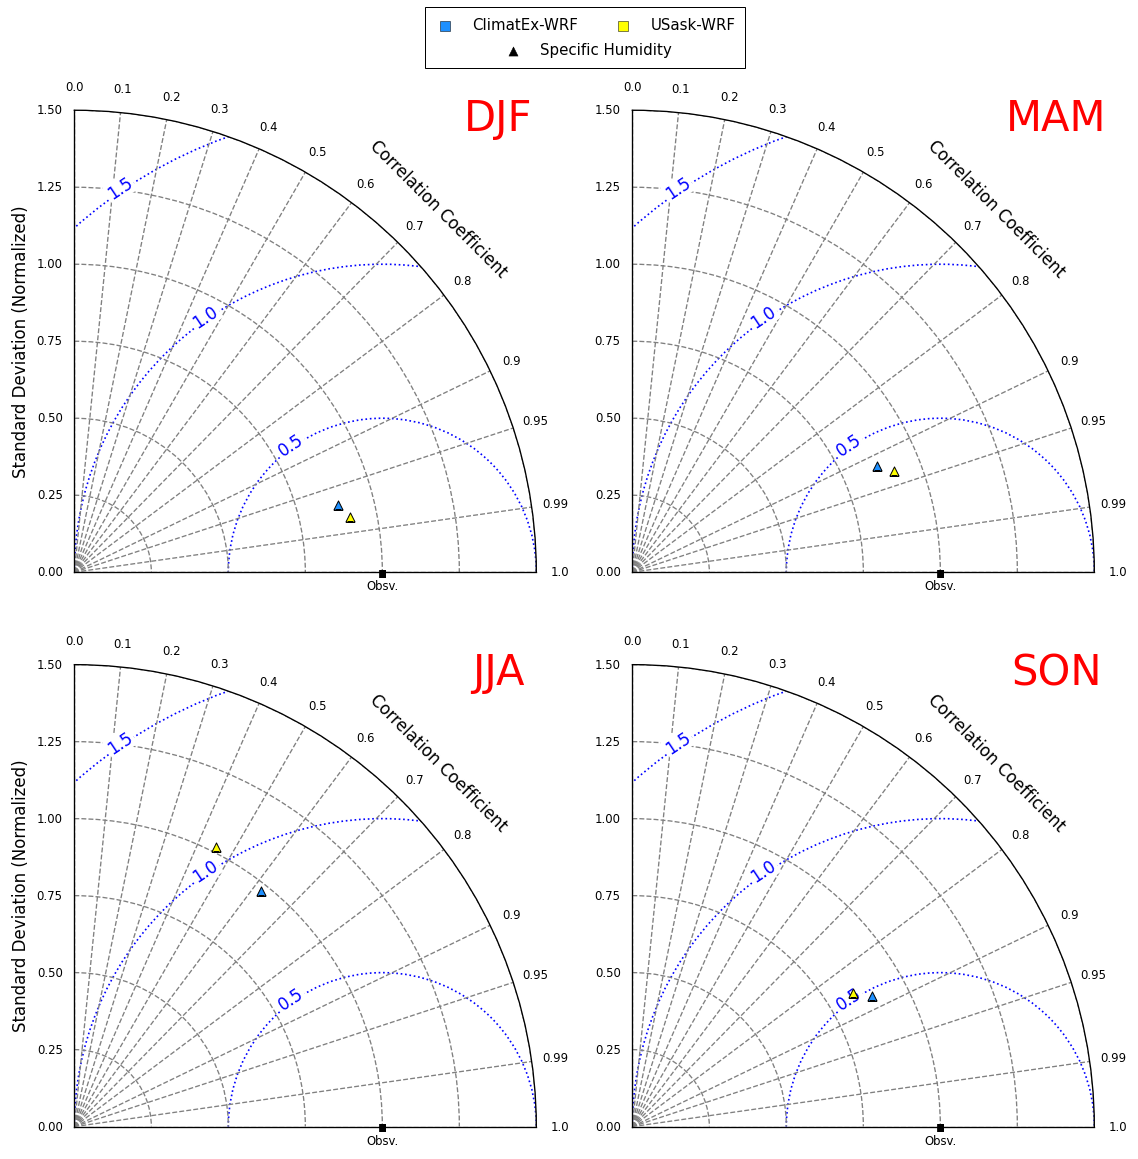

In [41]:
# JUST HUMIDITY

# ------------------------------------------------------------------
# Set up the plot structure
# ------------------------------------------------------------------

fig = plt.figure(figsize=(11, 11), dpi=120)
ax0 = fig.add_subplot(221, polar=True)
ax1 = fig.add_subplot(222, polar=True)
ax2 = fig.add_subplot(223, polar=True)
ax3 = fig.add_subplot(224, polar=True)
axes = [ax0, ax1, ax2, ax3]
initialize_axis(ax0, add_ylabel=True)
initialize_axis(ax1, add_ylabel=False)
initialize_axis(ax2, add_ylabel=True)
initialize_axis(ax3, add_ylabel=False)

# ------------------------------------------------------------------
# Plot the data on the Taylor diagram
# ------------------------------------------------------------------

markers = ['D', 'o', '^',]  # Denote variable (winds, winds dmax, humid)
colours = ['dodgerblue', 'yellow',]  # Denote Model (UBC WRF, USASK WRF)
std_norm, rms_norm, corr = [1.], [0.], [1.]

# Loop over each variable (winds, humid) and each season
i, var = (2, keys[2])
for j, season in enumerate(subkeys):
    
    print(f"Plotting {var} for {season}...")

    # compute taylor statistics for var (UBC WRF) and plot
    stats_ubc = sm.taylor_statistics(wrf_ubc_vals[var][season], stn_vals[var][season])
    std_norm.append(stats_ubc['sdev'][1] / stats_ubc['sdev'][0])
    rms_norm.append(stats_ubc['crmsd'][1] / stats_ubc['sdev'][0])
    corr.append(stats_ubc['ccoef'][1])
    if (corr[-1] < 0) or np.isnan(corr[-1]):
        print(f"WARNING: Negative or NaN correlation for variable {var} and season {season} in ClimatEx-WRF")
    plot_point(std_norm[-1], np.arccos(corr[-1]), marker=markers[i], col=colours[0], edgecol='k', ax=axes[j])
    # plot_point(std_norm[-1], np.arccos(corr[-1]), text=f"1", ax=axes[j], col='k')

    # compute taylor statistics for var (USASK WRF) and plot
    stats_usask = sm.taylor_statistics(wrf_usask_vals[var][season], stn_vals[var][season])
    std_norm.append(stats_usask['sdev'][1] / stats_usask['sdev'][0])
    rms_norm.append(stats_usask['crmsd'][1] / stats_usask['sdev'][0])
    corr.append(stats_usask['ccoef'][1])
    if (corr[-1] < 0) or np.isnan(corr[-1]):
        print(f"WARNING: Negative or NaN correlation for variable {var} and season {season} in USask-WRF")
    plot_point(std_norm[-1], np.arccos(corr[-1]), marker=markers[i], col=colours[1], edgecol='k', ax=axes[j])
    # plot_point(std_norm[-1], np.arccos(corr[-1]), text=f"2", ax=axes[j], col='k')

    # add text for specifying season in the top right of each subplot
    plot_point(2, np.pi/4, text=f"{season}", ax=axes[j], col='red', fs=25)

# legend
plot_point(-1, -1, marker='s', ax=axes[0], col=colours[0], fs=0, lw=0.3, label='ClimatEx-WRF')
plot_point(-1, -1, marker='s', ax=axes[0], col=colours[1], fs=0, lw=0.3, label='USask-WRF')
# plot_point(-1, -1, marker=markers[0], ax=axes[1], col='k', fs=0, lw=0.3, label='Wind Speed')
# plot_point(-1, -1, marker=markers[1], ax=axes[1], col='k', fs=0, lw=0.3, label='Wind Speed (Daily Maximum)')
plot_point(-1, -1, marker=markers[2], ax=axes[1], col='k', fs=0, lw=0.3, label='Specific Humidity')

axes[0].legend(loc='upper right', fontsize=9, frameon=False, ncols=2, bbox_to_anchor=(1.46, 1.23),)
axes[1].legend(loc='upper right', fontsize=9, frameon=False, ncols=3, bbox_to_anchor=(.25, 1.23),)
leg0 = axes[0].get_legend()
leg1 = axes[1].get_legend()
leg1.set_frame_on(True)
frame = leg1.get_frame()
frame.set_boxstyle("square,pad=0.28")
frame.set_facecolor("none")
frame.set_edgecolor("black")
frame.set_linewidth(0.6)
frame.set_alpha(1.0)
leg1.set_title("                                                         ", prop={"size": 10})

plt.show()